In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [2]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(), 
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


In [3]:
BASE_PATH = r"D:\Amrita\Semester-2\Deep Learning\Lab Evaluations\week-4\dataset"

train_dataset = datasets.ImageFolder(BASE_PATH + r"\train", transform=train_transforms)
val_dataset = datasets.ImageFolder(BASE_PATH + r"\valid", transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_dataset.classes)
print("Classes:", NUM_CLASSES)


Classes: 102


In [5]:
class FlowerCNN(nn.Module):
    def __init__(self, num_classes):
        super(FlowerCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),  
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FlowerCNN(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
EPOCHS = 15

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}], "
          f"Train Loss: {train_losses[-1]:.4f}, "
          f"Val Loss: {val_losses[-1]:.4f}, "
          f"Val Acc: {val_acc:.4f}")


Epoch [1/15], Train Loss: 4.3544, Val Loss: 3.8147, Val Acc: 0.1051
Epoch [2/15], Train Loss: 3.6819, Val Loss: 3.2798, Val Acc: 0.1858
Epoch [3/15], Train Loss: 3.3167, Val Loss: 2.9478, Val Acc: 0.2628
Epoch [4/15], Train Loss: 3.0509, Val Loss: 2.7463, Val Acc: 0.2910
Epoch [5/15], Train Loss: 2.8414, Val Loss: 2.6065, Val Acc: 0.3276
Epoch [6/15], Train Loss: 2.6277, Val Loss: 2.3817, Val Acc: 0.3839
Epoch [7/15], Train Loss: 2.4919, Val Loss: 2.2944, Val Acc: 0.3875
Epoch [8/15], Train Loss: 2.3303, Val Loss: 2.1673, Val Acc: 0.4328
Epoch [9/15], Train Loss: 2.2188, Val Loss: 2.1001, Val Acc: 0.4438
Epoch [10/15], Train Loss: 2.1245, Val Loss: 2.0805, Val Acc: 0.4377
Epoch [11/15], Train Loss: 2.0168, Val Loss: 2.0058, Val Acc: 0.4768
Epoch [12/15], Train Loss: 1.9412, Val Loss: 1.9399, Val Acc: 0.4841
Epoch [13/15], Train Loss: 1.8803, Val Loss: 1.9142, Val Acc: 0.4853
Epoch [14/15], Train Loss: 1.7973, Val Loss: 1.9601, Val Acc: 0.4768
Epoch [15/15], Train Loss: 1.7308, Val Loss

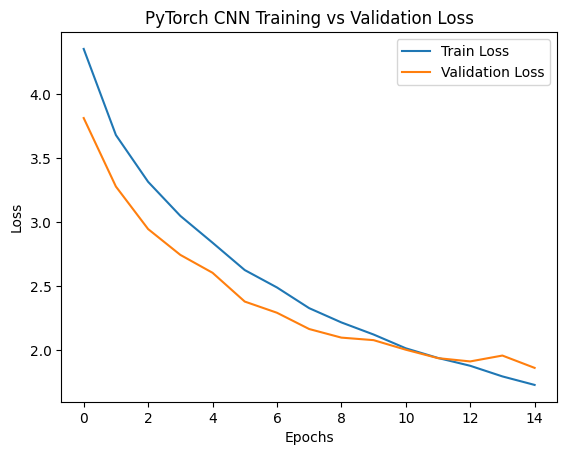

In [8]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("PyTorch CNN Training vs Validation Loss")
plt.legend()
plt.show()


In [9]:
print("Final Validation Accuracy:", val_accuracies[-1])


Final Validation Accuracy: 0.5232273838630807
